$$ \Large{\textbf{DNA Sequence Classification with Digital Signal Processing - FFT}} $$    
$$ \large{\textbf{Part IIb: ML Supervised Classification of Fungis DNA sequences}} $$
<br>
$$ \small{\textbf{Dr. Stéphane DEDIEU, Fall-Winter 2022. }} $$
<br>
<br>

# Introduction




<span style="color:#006699">   In this notebook we classify Fungi DNA sequences in 3 phylums (subphylums) with short FFT:  NFFT=1024 points, and the soft alignment method developped in Part IIa. 
<br> Initial runs with the method used in the Vertebrate dataset: birds-fishes-mammals, ML-FTT, Machine LEarning with short FFT of DNA sequences returned low accuracy. And it is impossible to properly identify Basidiomycota fungi. The number of DNA sequences is low in the Fungi dataset: 224. And only 30 in the Basidiomycota folder. Which makes the classification pretty challenging ! 

<b> Basidiomycota </b>

<span style="color:#006699">      From Wikipedia: <br> 
<i>"Basidiomycota is one of two large divisions that, together with the Ascomycota, constitute the subkingdom Dikarya (often referred to as the "higher fungi") within the kingdom Fungi. Members are known as basidiomycetes. More specifically, Basidiomycota includes these groups: mushrooms, puffballs, stinkhorns, bracket fungi, other polypores, jelly fungi, boletes, chanterelles, earth stars, smuts, bunts, rusts, mirror yeasts, and Cryptococcus, the human pathogenic yeast.  <br>
Basidiomycota that reproduce asexually (discussed below) can typically be recognized as members of this division by gross similarity to others, by the formation of a distinctive anatomical feature (the clamp connection), cell wall components, and definitively by phylogenetic molecular analysis of DNA sequence data.
 According to a 2008 estimate, Basidiomycota comprise three subphyla (including six unassigned classes) 16 classes, 52 orders, 177 families, 1,589 genera, and <b> 31,515 species" </b></i>.

https://en.wikipedia.org/wiki/Basidiomycota

http://www.davidmoore.org.uk/21st_century_guidebook_to_fungi_platinum/Ch03_08.htm 


<b> Pezizomycotina </b> 
    
<span style="color:#006699">    Pezizomycotina make up most of the division (phylum) <b> Ascomycota </b> fungi and include most lichenized fungi too. Pezizomycotina contains the filamentous ascomycetes and is a subdivision of the Ascomycota (fungi that form their spores in a sac-like ascus).

https://en.wikipedia.org/wiki/Pezizomycotina


<b> Saccharomycotina </b> 
    
<span style="color:#006699">   Saccharomycotina is a subdivision (subphylum) of the division (phylum) <b> Ascomycota </b> in the kingdom Fungi. It comprises most of the ascomycete yeasts. The members of Saccharomycotina reproduce by budding and they do not produce ascocarps (fruiting bodies)
    
https://en.wikipedia.org/wiki/Saccharomycotina

<table border="1" width='750px'>
    <caption style="text-align:center;color:black;font-size:18px;" ><b>Basidiomycota fungi</b> </caption>
    
<tr>
    <td> <img src="Neutari_(oyster_mushroom).jpg" alt="Drawing" style="width: 250px;"/> 
        <figcaption style="text-align:center;color:black;font-size:14px;"> <i>Pleurotus ostreatus</i> <br> Oyster Mushroom </figcaption> </td>
    <td> <img src="Schizophyllum_commune_(Split_gill)_(33389628036).jpg" style="width: 250px;"/> 
        <figcaption style="text-align:center;color:black;font-size:14px;"> <i> Schizophyllum commune </i> <br>      </figcaption>  </td>
    <td> <img src="440px-Cryptococcus_neoformans_using_a_light_India_ink_staining_preparation_PHIL_3771_lores.jpg" style="width: 250px;"/> 
         <figcaption style="text-align:center;color:black;font-size:14px;"> <i>Cryptococcus neoformans</i>  <br>
         (pathogenic encapsulated yeast)</figcaption> </td>
</tr>
<tr style='text-align:center; vertical-align:middle'></tr> 

<table border="1" width='750px'>
    <caption style="text-align:center;color:black;font-size:18px;" > <b> Pezizomycotina fungi </b> </caption>
<tr>
    <td> <img src="Neurospora-intermedia.jpg" style="width: 250px;"/> 
    <figcaption style="text-align:center;color:black;font-size:14px;"> <i> Neurospora intermedia <br> 
        (red oncom mold)</i></figcaption> </td>
</tr>
<tr style='text-align:center; vertical-align:middle'></tr> 
    
<table border="1" width='750px'>
     <caption style="text-align:center;color:black;font-size:18px;" ><b> Saccharomycotina fungi </b> </caption>
<tr>
    <td> <img src="800px-S_cerevisiae_under_DIC_microscopy.jpg" style="width: 250px;"/> 
    <figcaption style="text-align:center;color:black;font-size:14px;"> <i> Saccharomyces cerevisiae <br> 
        (brewer's yeast)</i> </figcaption> </td>
    
</tr>
<tr style='text-align:center; vertical-align:middle'></tr> 

<b> Dataset </b>

<span style="color:#006699"> Fungi dataset used by Gurjit S. Randhawa et al. has a total count of : 224 DNA sequences. And only 30 DNA sequences for phylum "Basidiomycota", which includes thousands of species. This makes supervised classification particularly challenging. Also the fact that we operate in a similar subkingdom: fungi, with close characteristics in terms of mitochondrial genomes.     

    
| Phylum   | Genomes     |  DNA sequence    |    
| ---      | ---         | ---              |
|          | (count)     |  (min-max length) |
| Basidiomycota   |   30       | 9745 / 235849 |
| Pezizomycotina   | 104       | 1364 / 203051 |
| Saccharomycotina | 90        |18844 / 107123 |  

  
Data source: https://www.ncbi.nlm.nih.gov/labs/gquery/all/?term=NC_001224.1

## Methodologies



### ML-DSP 
<br>
<span style="color:#006699">  
The ML-DSP method proposed by Gurjit S. Randhawa et al. [1] reached 100% accuracy with the vertebrates dataset: Birds-Fish-Mammals. <br> With the Fungi datatse, accuracy is lower: 89% maximum, depending on the algorithm and numerical representation (we say encoding). The authors propose a synthetic table with Fungi results in the article [1]. It is shown below.


 <img src="Table_FUNGI.jpg" alt="drawing" width="750"/>  
 <figcaption style="text-align:center;color:black;font-size:14px;"> <i>Fungi classification accuracy - <b>ML-DSP results</b> with various ML techniques <br> and DNA sequences numerical coding. </i> </figcaption>

<span style="color:#006699">  Best results were achieved with "PP" numerical encoding and subspace KNN classifier: <b>Accuracy is 89.3%</b> <br> 
No confusion matrix was provided by the authors for this dataset. <br>
We will use the same numerical encoding method: "PP" but more options can be tested with the notebook.      

###  Our methodology: ML-FFT  
<br>
<span style="color:#006699"> Our simple method ML-FFT used in Bird-Fish-Mammals classification, <b><i>fails to properly identify Basidyomicota species </i></b>. <br> After hyperparameters optimization, cross-validation with k=10, best results were achieved with SVM and a 'rbf' Kernel. <br> They are presented below. Accuracy is 79%, but there are too many False Negatives. Discriminating Basidiomycota species (DNA sequences) from Pezizomycotina species proves difficult.    


<img src="MLFFT_FUNGI_ClassificationReport_pictureConfusion.png" alt="drawing" width="900"/>  
<figcaption style="text-align:center;color:black;font-size:14px;"> <i>Fungi classification accuracy - <b>Best ML-FFT results</b> </i> </figcaption>

###  Improved Methodology ML-FFT + Soft Alignment 
<br>
<span style="color:#006699"> 

Note that the ML-DSP method proposed by Gurjit S. Randhawa et al. [1] is intended to prevent the use of costly alignment algorithms. Any alignment strategy makes sense: <br>
- if it is fast <br>
- if accuracy is significantly higher than reference 89.3%. In similar conditions: optimization of hyperparameters, cross-validation=10.<br>   

Due to fungi DNA sequence minimum length ($<2048$), in this study we cannot compute FFT with NFFT=2048 points. Therefore we set NFFT=1024. <br>      
In part IIa, we proposed a simple alignment method based on cross-correlation. The method allowed the following: <br>
- defining a NFFT=1024 reference frame for each phylum. The process was relatively fast, but the cardinal of dataset is low: 20 sequences per phylum.<br>
- selecting frames in each DNA sequence, "optimal frames", that align best with the 3 reference frames. <br> 
    
In Part IIa, alignment was validated with the "alignment Dataset". In this notebook, we will verify "alignment" with the classification dataset before computing FFT and run classification algorithms. <br>

After selecting optimal NFFT =1024 frames for each DNA sequence in each phylum, we apply the simple method ML-FFT defined in part I: Birds-Fishes-Mammals. With spectrum magnitude and phase. Or spectrum magnitude only.  
    <br>

# Results

<span style="color:#006699"> Results depend on the reference frames matrix. With PP numerical encoding, optimal frames, short FFT (NFFT=1024), best accuracy <b>is between 94% and 98%</b>. <b> Which is a significant improvement over the ML-DSP method</b> at a reasonable cost: alignment optimization time.<br> Best results are achieved with reference frame <code>'BPS_PP_RefFrame_1024_d4_v10.npy'</code> identified in Part IIa (check parameters in Part IIa). <br> 
They are presented below: <br>
<br>

    
   
    
| Approach  | Accuracy  |      ML Technique   |
| ---      | ---         |   ---      |
|NFFT= 1024 points Magnitude only (512 features)  | <b> 96% </b>    |  Logistic Regression newton-cg solver <br> SVM "rbf" solver  |
|NFFT= 1024 points Magnitude + Phase (1024 features) | <b> 98% </b>    |  Logistic Regression newton-cg solver         |


<br> 
       
<span style="color:#006699"> In general, <b><i>accuracy is around 96%.</i></b>. We were a bit <b>lucky</b> with logistic regression and FFT spectrum magnitude+phase (1024 features), <b><i>with an accuracy above 98%.</i></b> This is the result we display below. <br>   

     
<table border="1" width='750px'>
<tr>
    <td> <img src="LOG_REG_Fungi_accuracy.png" alt="Drawing" style="width: 450px;"/> 
        <figcaption style="text-align:center;color:black;font-size:14px;"> <i>Classification accuracy</i> </figcaption> </td>
    <td> <img src="LOG_REG_Fungi_ConfusionMatrix.png" style="width: 450px;"/> 
        <figcaption style="text-align:center;color:black;font-size:14px;"> <i> Confusion Matrix </i> </figcaption>  </td>

</tr>
<tr style='text-align:center; vertical-align:middle'></tr> 
<table border="1" width='750px'>   
<tr>    
    <figcaption style="text-align:center;color:black;font-size:14px;"> <i> <b>Best ML-FFT+Align</b> results with Logistic regression - solver: newton-cg  </i> </figcaption>
</tr>    

 
<br>
<br>
<span style="color:#006699"> <b> Thanks to the alignment method, Basidyomicota DNA sequences were perfectly identified in the test set. </b>  It was also the case with the model with 96% accuracy. 

# Conclusions


<br>
<span style="color:#006699"> 
<b>Thanks to the soft alignment method developped in Part IIa, and the selection of optimal NFFT frames for each DNA sequence in Fungi phylums datasets, we significantly outperformed ML-DSP method presented in [1] </b>. <br>
<br>
Alignment was achieved with a small number of sequences: 20 per phylum in Part IIa. <br>
We can extend the soft alignment method to a higher number of phylums or classes, and still identify reference frames in a reasonable time. <br> 
In Part III, we will apply the same technique ML-FFT+ Soft Alignment to new datasets: <b> Protists (small), Insects (large dataset). </b> <br>
<br>    
Further research will test spectrograms, wavelets, and Deep Learning algorithms on large datasets.<br>
<br>
<br>

# References




##  Required libraries

In [1]:
from IPython.display import Image
from IPython import display
#display.Image("./image.png")
#Image(filename='image.png')

In [2]:
#--------------------------------------------
# Notebook wide presentation
#--------------------------------------------
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

#-------  For centering figures 
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [3]:
#!pip install  requests

In [6]:
import requests
#import nsdpy

In [7]:
import time
import random
from scipy import signal
from skimage import util

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
#--------------------------------------------
# Sklearn ML Algos
#--------------------------------------------
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

In [10]:
#--------------------------------------------
# Sklearn metrics
#--------------------------------------------
from sklearn.metrics import jaccard_score
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [11]:
#--------------------------------------------
# IMPROVED CONFUSION MATRIX
#--------------------------------------------

def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    #sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    sns.heatmap(cm, square=True, annot=True, annot_kws={'fontsize':16}, fmt="d", cmap='Blues', cbar=True)  # modified for cosmetic reasons. We want beauty. 
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
 
    ax.xaxis.set_ticklabels(['Basid.', 'Peziz.', 'Sacchar.']);ax.yaxis.set_ticklabels(['Basid.', 'Peziz.', 'Sacchar.'])

In [12]:
import string
import screed # A Python library for reading FASTA and FASQ file format.
def readFastaFile(inputfile):
    """
    Reads and returns file as FASTA format with special characters removed.
    """
    with screed.open(inputfile) as seqfile:
        for read in seqfile:
            seq = read.sequence
    return seq

# Reading Data - FASTA/FASQ File

<b> Requests:   RefSeq AND Basidiomycota AND DNA AND complete AND genome  </b> 

In [13]:
#----------
# At the moment and for validation purposes, we keep all conversion steps separated. 
#---------- 
def conversion_DNA_str(X,Y,instr, outstr):
        for j in range(0,len(X)):
            Y.append(X[j].translate({ord(x): y for (x, y) in zip(instr, outstr)}))        
        return Y
#----------    
def conversion_DNA_num(X,Y):
        for j in range(0,len(X)):
            Y.append([int(x) for x in str(X[j])])     
        return Y

<span style="color:#006699"> We start with downloading all fungi files in various sub-folders: Basidiomycota, Pezizomycotina, Saccharomycotina. <br>
Files are stored locally.

<span style="color:#006699"><b>Note:</b> we will keep the 3 genres DNA sequences in 3 distinct lists and then matrices for analysis, visualization and validation purposes. <br> In the end, all genres DNA sequences FFT "spectrums" are appended in a unique dataframe for supervised classification.   

In [14]:
import glob
import re
import os

fungi_folder= "MLDSP-master/DataBase/Fungi"   #  CHANGE YOUR PATH HERE 

fungi_Basidiomycota = glob.glob(fungi_folder + '/Basidiomycota/' + 'F*.txt') # 
fungi_Pezizomycotina = glob.glob(fungi_folder + '/Pezizomycotina/' + 'F*.txt') 
fungi_Saccharomycotina = glob.glob(fungi_folder + '/Saccharomycotina/' + 'F*.txt') 

fungi_B = []
fungi_P=  []
fungi_S=  []

for fname in fungi_Basidiomycota:
    fungi_B.append(readFastaFile(fname))
    
for fname in fungi_Pezizomycotina:
    fungi_P.append(readFastaFile(fname))

for fname in fungi_Saccharomycotina:
    fungi_S.append(readFastaFile(fname))

print(type(fungi_B))
print(np.shape(fungi_B), np.shape(fungi_P), np.shape(fungi_S))
print(len(fungi_B[0]))
print(len(fungi_B[1]))
print(len(fungi_B[2]))
print(len(fungi_B[3]))
print(fungi_B[1][0:10])

<class 'list'>
(30,) (104,) (90,)
9879
31825
32520
9745
ATGAAAACAT


<span style="color:#006699"> 
We implement a PP (Purine/Pyrimidine) representation.  <br>
T,C ---> 1 <br>
A,G ---> -1   <br>
For practical purposes we start encoding with strings "0","2" and we will substract 1 when numerical DNA sequences are created.   

In [15]:
#------------------
#  Testing various types of numerical representations. 
#------------------
instr = "TCAG"
#outstr = "0010"; cornr= 0.5    #  Just A representation 
#outstr = "1234"    #  Integer representation I
#outstr = "0123";  cornr= 1.5     #  Integer representation II
outstr = "2200"; cornr=1    #  PP representation  [T,C]= 1, [A,G]= -1  Must substract 1 in all DNA sequences matrices  ! 
#---------
DNA_FB=[]
DNA_FP=[]
DNA_FS=[]
#---------
DNA_FB=conversion_DNA_str(fungi_B, DNA_FB,instr, outstr)
DNA_FP=conversion_DNA_str(fungi_P, DNA_FP,instr, outstr)
DNA_FS=conversion_DNA_str(fungi_S, DNA_FS,instr, outstr)
#--------- 
FB=[]
FP=[]
FS=[]
#---------
FB=conversion_DNA_num(DNA_FB,FB)
FP=conversion_DNA_num(DNA_FP,FP)
FS=conversion_DNA_num(DNA_FS,FS)

In [16]:
len(FB), len(FP), len(FS) 

(30, 104, 90)

<span style="color:#006699"> Conversion List ---> Matrix (2D np.array)

In [17]:
Mat_DNA_FB = np.array([np.array(x) for x in FB], dtype=object)  -cornr 
Mat_DNA_FP = np.array([np.array(x) for x in FP], dtype=object)  -cornr
Mat_DNA_FS = np.array([np.array(x) for x in FS], dtype=object)  -cornr 

In [18]:
print(fungi_B[0][0:10])
print(FB[0][0:10])
print(Mat_DNA_FB[0][0:10])

GGGGGTATAC
[0, 0, 0, 0, 0, 2, 0, 2, 0, 2]
[-1 -1 -1 -1 -1  1 -1  1 -1  1]


<span style="color:#006699"> 
Numerical encoding looks fine. <br>
We determine minimum and maximum lengths of DNA sequences.  

In [19]:
lenkb= np.empty(len(Mat_DNA_FB)).astype(int) 
lenkp= np.empty(len(Mat_DNA_FP)).astype(int) 
lenks= np.empty(len(Mat_DNA_FS)).astype(int) 

for k in range(len(Mat_DNA_FB)) :
    lenkb[k]=len(Mat_DNA_FB[k])
    
for k in range(len(Mat_DNA_FP)) :
    lenkp[k]=len(Mat_DNA_FP[k])

for k in range(len(Mat_DNA_FS)) :
    lenks[k]=len(Mat_DNA_FS[k])

In [20]:
min_b = pd.Series(lenkb).min() 
min_p = pd.Series(lenkp).min() 
min_s = pd.Series(lenks).min() 
max_b = pd.Series(lenkb).max() 
max_p = pd.Series(lenkp).max() 
max_s = pd.Series(lenks).max() 
print('Min length DNA seq. B,P,S: ',min_b, min_p, min_s)
print('Max length DNA seq. B,P,S: ',max_b, max_p, max_s)

Min length DNA seq. B,P,S:  9745 1364 18844
Max length DNA seq. B,P,S:  235849 203051 107123


<span style="color:#006699"> Large DNA seuqnec length discrepancy. If we could select the foirst NFFT=-2048 point of each sequence in Part I, we had to go through the alignement process for defining optimal framnes <br>   
In any case we don't work with the full sequnce so we don't have to worry about the variable length. 

# EDA - Analysis 

## Analysis: Comparing DNA sequences. 
<br>
<span style="color:#006699"> 
We focus on the most difficult fungi genre. We had trouble classifying:  Basidiomycota.  <br>
We can check that numerical representations are fine.
We can see similar patterns, with repetition of nucleotides, particularly when comparing B[1] and B[2].   

In [22]:
print("First Basidiomycota, Pezizomycotina, Saccharomycotina fungi DNA sequences and Just A numerical representation (first 30 nucleotides).")
print("  ")
print("B[0]: ", fungi_B[0][0:100])
#print(Mat_DNA_FB[0][0:30])
print("B[1]: ", fungi_B[1][0:100])
#print(Mat_DNA_FB[0][0:30])
print("B[2]: ", fungi_B[2][0:100])
#print(Mat_DNA_FB[0][0:30])
print("  ")
print("P[0]: ",fungi_P[0][0:100])
#print(Mat_DNA_FB[1][0:30])
print("P[1]: ",fungi_P[1][0:100])
#print(Mat_DNA_FB[1][0:30])
print("P[2]: ",fungi_P[2][0:100])
#print(Mat_DNA_FB[2][0:30])
print("  ")
print("S[0]: ",fungi_S[0][0:100])
#print(Mat_DNA_FB[3][0:30])
print("S[1]: ",fungi_S[1][0:100])
#print(Mat_DNA_FB[3][0:30])
print("S[2]: ",fungi_S[2][0:100])
print("  ")
print("Mat_DNA_FS[2][0:50]", Mat_DNA_FS[2][0:25])

First Basidiomycota, Pezizomycotina, Saccharomycotina fungi DNA sequences and Just A numerical representation (first 30 nucleotides).
  
B[0]:  GGGGGTATACAACAGCTGTCTATTTTAAGAAAGTTATATTTTCCGATCGCTCTTATGATGAAAAGAATATTTAATAATTTATTTTCTAGATTTGATAATC
B[1]:  ATGAAAACATGATAAAAGATAAAGTGATCTTAATGAGTATTTAAGCAGGCTGTAAGAAGGAGTGTCAAGAGGCATAAATATTCGTAAGTAAGGATAGATT
B[2]:  ATGAAAACATGATAAAAGATAAAGTGATCTTAATGAGTATCTCTGCAGGCTGTAATAAAGAATGTCAAGAGGCATAAATATTTGTAGGTACGTAAAAGTA
  
P[0]:  AGCAAACAATCTTTTAATTCTAAATTGTGTTAAACCTAATACAGAACCAATTACTAAACCTAATAATGAACTTATTAAGAAACTAGTAGTTCAAGTATAT
P[1]:  GAGACTTTGGCTTAATTGGTAAAGCATGTGCCTTTTAATCACTATTATATGGGTTCAAATCCCATAGGTCTTATATTAGTAAGCGGCTATAAGTTAATGG
P[2]:  GGCTACGCGGCTACGCGGCTACGCGGCTACGCAAACCTAGGTTTGCGTAGCCGCGTAGCCAGCCGAAGGAAAAATAAAAAGTATTTTAGCCAGTATAATA
  
S[0]:  TTCATAATTAATTTTTTATATATATATTATATTATAATATTAATTTATATTATAAAAATAATATTTATTATTAAAATATTTATTCTCCTTTCGGGGTTCC
S[1]:  ACAGGGTAATATAACGAAATAGTACATATAGTAAGTTATGTTTGCCACCTCGATGTCGACTCGCCTTATCCTATTGGTTGTAGCAGCTAATAAG

<span style="color:#006699"> 

<b> We can identify similarities in DNA sequences of Basidiomycota fungi B1 and B2.</b><br>
Note that each specie in each class or phyllum has DNA sequence with different length. Eventually when we select a frame and compute the FFT, each spoecies in each phyllum will have similar length, NFFT//2.    

In [23]:
print("Length of Basidiomycota 1st DNA sequence: ",  len(Mat_DNA_FB[0]), " |||  Length of Basidiomycota 2nd DNA sequence: ", len(Mat_DNA_FB[1]))

Length of Basidiomycota 1st DNA sequence:  9879  |||  Length of Basidiomycota 2nd DNA sequence:  31825


In [24]:
print("Number of DNA sequences:, Basidiomycota: ", Mat_DNA_FB.shape," Pezizomycotina: ", Mat_DNA_FP.shape, " Saccharomycotina: ", Mat_DNA_FS.shape)

Number of DNA sequences:, Basidiomycota:  (30,)  Pezizomycotina:  (104,)  Saccharomycotina:  (90,)


<span style="color:#006699"> 

The question now is how to select a frame, in the same phylum knowing that 
We propose a "soft" alignement, where frames of significant length will be involved. The idea is to maximize cross-correlation, i.e. selecting frames so that some patterns locally are similar to the patterns in a reference frame.   

## DNA Sequences Alignment 

### Determining optimal DNA sequence reference frames

SYNTHESIS: 

<span style="color:#006699"> 

At that point we assume that we don't know the class or label of DNA sequences. We run the alignment procedure and compare each subframe in the tested DNA sequence, and select the subframe that aligns best with any of B, F, S reference frame.  
We run an alignmeent procedure. We will see that the processs does not guarantee that frames in a phylum aligns with the reference frame in that phylum.  
     
The process was already explained in Part IIa. In each phylum:
    
- we split all DNA sequences in frames, length NFFT= 1024 points. <br>
- we compare each frame with B, P, S reference frames, using corss-correlation as illustrated in the Figure below. <br> 
- we select the best match for each phylum, and check the percentage of DNA sequence optimal frame properly aligned.<br>
    
Testing alignment with test set.   
Each DNA squence in each phyllum Mat_# is split into frames. Each frame is compared with the 3 reference frames:  <br> 
The DNA sequence frame maximizing cross-correlation will be saved.  <br>
We will check if: <br>
- DNA sequence in each phyllum aligns with the phyllum reference frame. In this case we expect the classification model trained with the train set, to perfroem model <br>
- some DNA sequences align with another phyllum reference frame.  In this case we expect that the classification model accuracy will degrade with the test set.  

 <img src="Fungi_Alignment.png" alt="drawing" width="950"/>  

In [25]:
import time

In [26]:
seq_length=1024      
step_l=seq_length//8 # overlap when sliding window/frame on DNA sequence under test

In [27]:
import numpy as np
from numpy.fft import fft, ifft, fft2, ifft2, fftshift

def cross_correlation_using_fft(x, y):
    f1 = fft(x)
    f2 = fft(np.flipud(y))
    cc = np.real(ifft(f1 * f2))
    return fftshift(cc)
    #return cc
# shift < 0 means that y starts 'shift' time steps before x # shift > 0 means that y starts 'shift' time steps after x
#def compute_shift(x, y):
#    assert len(x) == len(y)
#    c = cross_correlation_using_fft(x, y)
#    assert len(c) == len(x)
#    zero_index = int(len(x) / 2) - 1
#    shift = zero_index - np.argmax(c)
#    return shift

In [112]:
def DNA_frames_alignment_v10(Mat_DNA, Ref_Frame, seq_length, step_l):

    align_start= time.time()
    print('Running')
    eps=1e-6;
    Optimal_Frame=np.empty([len(Mat_DNA), seq_length ]).astype(float) 
    #Optimal_k=np.empty(len(Mat_DNA)).astype(float) 
    Optimal_k=np.empty(len(Mat_DNA)).astype(int)     
    #-----------------------------------------
    for j in range(len(Mat_DNA)):   # we took a frame in Mat_DNA[id_seq_ref] as a REFERENCE
    #-----
        frames = util.view_as_windows(Mat_DNA[j], window_shape=(seq_length,), step=step_l)   #  AVERAGING FULL LENGTH 
        max_cross_corr=np.empty([len(frames),len(Ref_Frame)]).astype(float)
    #--------
        for i in range(len(frames)):

                for k in range(len(Ref_Frame)) :
                    frameRef=Ref_Frame[k] # for each possible reference frame 
                    max_cross_corr[i,k] = eps*np.random.uniform(0, 1) + \
                                        np.max(cross_correlation_using_fft(frames[i], frameRef)) 
                
        indices = np.where(max_cross_corr == max_cross_corr.max())
        indices = np.array(indices)
        Optimal_Frame[j]= frames[indices[0]]
        Optimal_k[j]=indices[1]

    align_end=time.time()    
    print(f'Alignment computing time (s) {align_end - align_start:.2f}') 

    return Optimal_Frame, Optimal_k

####  Compare all DNA sequences frames with reference frames. 
<br>
<span style="color:#006699"> 
    
Selecting optimal frames in each phylum.  
Checking alignment. <br>
We download optimal or reference frames computed in Part IIa: 

In [113]:
Ref_Frame=np.load('BPS_PP_RefFrame_1024_d4_v10.npy')    

In [114]:
Optimal_Frame_FB_Align, Optim_kb =DNA_frames_alignment_v10(Mat_DNA_FB, Ref_Frame, seq_length, step_l)

Running
Alignment computing time (s) 0.02


C:\Users\drste\AppData\Local\Temp\ipykernel_12344\4294100749.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Optimal_k[j]=indices[1]


In [115]:
Optimal_Frame_FP_Align, Optim_kp =DNA_frames_alignment_v10(Mat_DNA_FP, Ref_Frame, seq_length, step_l)

Running
Alignment computing time (s) 0.05


C:\Users\drste\AppData\Local\Temp\ipykernel_12344\4294100749.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Optimal_k[j]=indices[1]


In [116]:
Optimal_Frame_FS_Align, Optim_ks =DNA_frames_alignment_v10(Mat_DNA_FS, Ref_Frame, seq_length, step_l)

Running
Alignment computing time (s) 0.05


C:\Users\drste\AppData\Local\Temp\ipykernel_12344\4294100749.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Optimal_k[j]=indices[1]


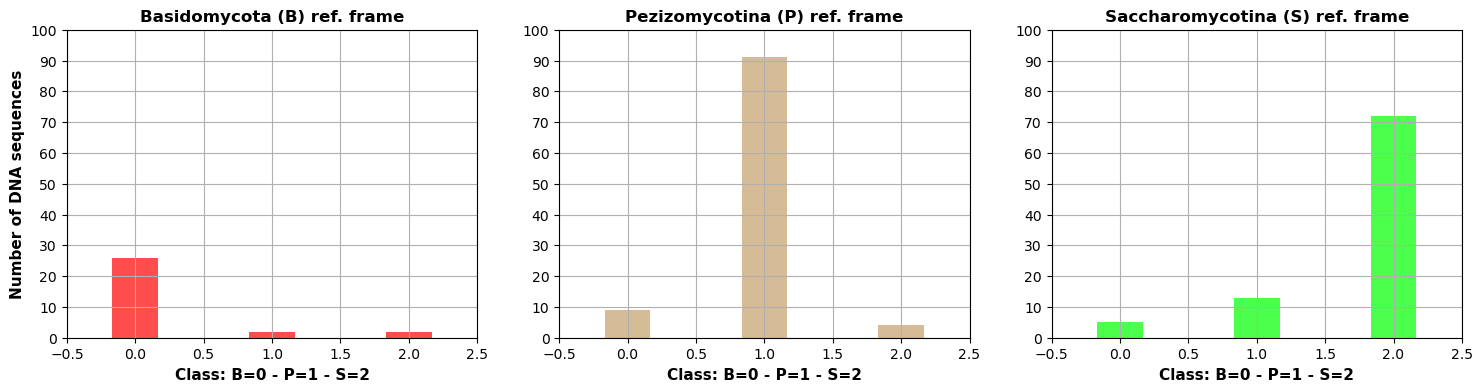

In [117]:
fig, axs = plt.subplots(1,3, figsize=(18,4))

# Fixing bin edges
HIST_BINS = np.linspace(-0.5, 2.5,10)
custom_ticks = np.linspace(0, 100, 11, dtype=int)

axs[0].hist(Optim_kb, HIST_BINS,  color='red', alpha=0.7)  
axs[0].set_xlim([-0.5,2.5])
axs[0].set_ylim([0,100])
axs[0].set_xlabel('Class: B=0 - P=1 - S=2', fontsize=11, weight='bold' )
axs[0].set_ylabel('Number of DNA sequences', fontsize=11, weight='bold' )
axs[0].set_title('Basidomycota (B) ref. frame', fontsize=12, weight='bold' )
axs[0].set_yticks(custom_ticks)
axs[0].grid()

axs[1].hist(Optim_kp,  HIST_BINS,  color='tan', alpha=0.9)         
axs[1].set_xlim([-0.5,2.5])
axs[1].set_ylim([0,100])
axs[1].set_xlabel('Class: B=0 - P=1 - S=2', fontsize=11, weight='bold' )
axs[1].set_title('Pezizomycotina (P) ref. frame', fontsize=12, weight='bold' )
axs[1].set_yticks(custom_ticks)
axs[1].grid()

axs[2].hist(Optim_ks,  HIST_BINS,  color='lime', alpha=0.7) 
axs[2].set_xlim([-0.5,2.5])
axs[2].set_ylim([0,100])
axs[2].set_xlabel('Class: B=0 - P=1 - S=2', fontsize=11, weight='bold' )
axs[2].set_title('Saccharomycotina (S) ref. frame', fontsize=12, weight='bold' )
axs[2].set_yticks(custom_ticks)
axs[2].grid()

plt.show()

In [118]:
np.unique(Optim_kb, return_counts=True), np.unique(Optim_kp, return_counts=True), np.unique(Optim_ks, return_counts=True)

((array([0, 1, 2]), array([26,  2,  2], dtype=int64)),
 (array([0, 1, 2]), array([ 9, 91,  4], dtype=int64)),
 (array([0, 1, 2]), array([ 5, 13, 72], dtype=int64)))

In [119]:
len(Optim_kb), len(Optim_kp), len(Optim_ks)

(30, 104, 90)

#### Alignment:           

| DNA sequences  -  Input              | Ref. Basidomycota  | Ref.  Pezizomycotina  |  Ref. Saccharomycotina    | Total # of DNA sequences |
| ---               |    ---        |      ---         |     ---    |  ---  |         
| A_Basidomycota      |    26         |       2          |        2             |     30    |
| A_Pezizomycotina    |    9          |      91          |        4             |     104    |
| A_Saccharomycotina  |    5          |       13          |        72            |     90    |

<span style="color:#006699"> 
    
The alignement process with reference frames is satifying. It is like a pre-classification process. <br>
Let see how it will help with the global classification problem. <br>
We save optimal reference frame for computing spectrums. 

In [120]:
Mat_DNA_FB=Optimal_Frame_FB_Align
Mat_DNA_FP=Optimal_Frame_FP_Align
Mat_DNA_FS=Optimal_Frame_FS_Align

In [121]:
Mat_DNA_FB.shape,  Mat_DNA_FP.shape, Mat_DNA_FS.shape

((30, 1024), (104, 1024), (90, 1024))

##  DNA Sequences Spectrums. 

<span style="color:#4169E1">  The process is similar to Part I: Birds-Fishes-Mammals. With similar windowing and filtering.  NFFT=1024 and a virtual sampling frequency fs. 

In [122]:
#-----------------------
#NFFT = 256      # number of bins for the FFT
NFFT=1024
SubSeq_L= seq_length   # sub sequence length
st=NFFT      # overlap when averagiung FFT for each frame
#st=NFFT     # overlap when averagiung FFT for each frame
win = np.hanning(NFFT + 1)[:-1]      # window for each frame
#win = np.blackman(NFFT + 1)[:-1]      # window for each frame
#win = np.hamming(NFFT + 1)[:-1]      # window for each frame
#win=np.ones(NFFT + 1)[:-1]  # No window 

In [123]:
import math   
fs=48000  
#----
xx= np.arange(0, NFFT//2, 1, dtype=int)
xx=xx*fs/NFFT
print(len(xx))
print(xx[0:10])

512
[  0.     46.875  93.75  140.625 187.5   234.375 281.25  328.125 375.
 421.875]


512 <class 'numpy.ndarray'>


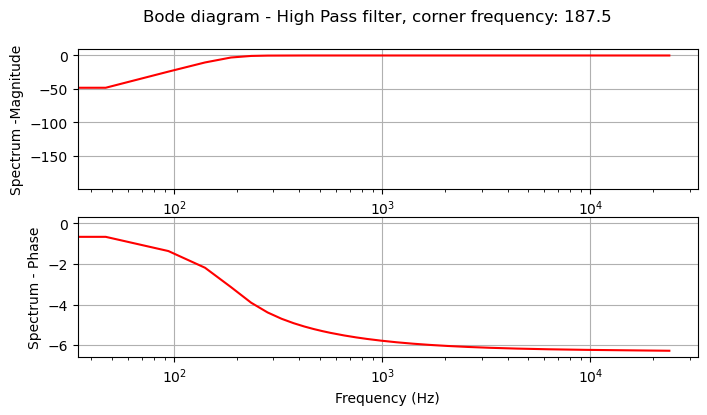

In [128]:
order=4
normal_cutoff=4*fs/NFFT
#----
b, a = signal.butter(order, normal_cutoff, btype='highpass', analog=False, output='ba', fs=fs)
wbutt, hbutt = signal.freqz(b, a,  worN=len(xx),fs=fs)
#----
print(len(wbutt), type(hbutt))
fig, axs = plt.subplots(2, figsize=(8,4))
fig.suptitle("Bode diagram - High Pass filter, corner frequency: "+ str(normal_cutoff) )
axs[0].semilogx(xx,20*np.log10(abs(hbutt[0:NFFT//2])),color='r')
axs[0].set_xlabel("Frequency (Hz)") 
axs[0].set_ylabel("Spectrum -Magnitude")
axs[0].grid()
#axs[0].grid(b=True, which='major', color='grey', linestyle='-')
#axs[0].grid(b=True, which='minor', color='grey', linestyle='--')
#------------------------------------------------------------

axs[1].semilogx(xx,np.unwrap(np.angle(hbutt[0:NFFT//2])),color='r')
axs[1].set_xlabel("Frequency (Hz)") 
axs[1].set_ylabel("Spectrum - Phase")
axs[1].grid()
#axs[1].grid(b=True, which='major', color='grey', linestyle='-')
#axs[1].grid(b=True, which='minor', color='grey', linestyle='--')

In [134]:
# Fonction FFT spectrum. Optimum results when we average on two frames without overlap. No windowing !   
def FFT_spectrum(Mat_DNA, NFFT, SubSeq_L, st, win):
    spectrum_F= np.empty([len(Mat_DNA),  NFFT//2]).astype(complex)
    
    for j in range(0,len(Mat_DNA)):
    
        frames = util.view_as_windows(Mat_DNA[j][0:SubSeq_L], window_shape=(NFFT,), step=st)  #   AVERAGING on SubSequence length SubSeq_L
        frames_win=frames*win  #  WINDOWING
        spectrum_cplx  = np.fft.fft(frames_win)
        # Mean of all slice FFT
        spectrum_F[j][:]= np.mean(spectrum_cplx, axis=0)[0:NFFT//2]                 #   AVERAGING
    
    return spectrum_F

In [132]:
from scipy import signal
from skimage import util
import scipy.signal

# Fonction FFT spectrum.
def FFT_spectrum_ba(Mat_DNA, NFFT, SubSeq_L, st, win,b,a) :  #, spec_filter):
    spectrum_F= np.empty([len(Mat_DNA),  NFFT//2]).astype(complex)  
    for j in range(0,len(Mat_DNA)):  
        # AVERAGING on SubSequence length SubSeq_L
        frames = util.view_as_windows(Mat_DNA[j][0:SubSeq_L], window_shape=(NFFT,), step=st)
        # AVERAGING on full length DNA sequences
        #frames = util.view_as_windows(Mat_DNA[j], window_shape=(NFFT,), step=st)
        frames_win=scipy.signal.filtfilt(b, a,frames*win) #  WINDOWING
        spectrum_cplx  = np.fft.fft(frames_win)   # DOUBLE SIDED spectrum !!   
        # Average all frames FFT
        spectrum_F[j][:]= np.mean(spectrum_cplx, axis=0)[0:NFFT//2]  #  AVERAGING if SubSeq_L>NFFT
        #spectrum_F[j][:]= np.mean(spectrum_cplx, axis=0)[NFFT//2:NFFT]  #  AVERAGING if SubSeq_L>NFFT    
    return spectrum_F

In [135]:
#---  Frequency response (half of spectrum)
spectrum_FB= FFT_spectrum(Mat_DNA_FB, NFFT, SubSeq_L, st, win)
spectrum_FP= FFT_spectrum(Mat_DNA_FP, NFFT, SubSeq_L, st, win)
spectrum_FS= FFT_spectrum(Mat_DNA_FS, NFFT, SubSeq_L, st, win)

In [136]:
spectrum_FB=hbutt*spectrum_FB
spectrum_FP=hbutt*spectrum_FP
spectrum_FS=hbutt*spectrum_FS

In [137]:
spectrum_FB.shape, spectrum_FP.shape, spectrum_FS.shape

((30, 512), (104, 512), (90, 512))

<span style="color:#4169E1">  We now have 3 half spectrums complex matrices with NFFT//2 columns. <br> We can extract spectrums magnitude and phase and append all of them into a dataframe. <br> We will add a "Class" column, for example Class=0: Fish, 1: Birds, 2: Mammals. Column "Class" will serve as label in a supervised classification problem. 

### Spectrums - Example 1

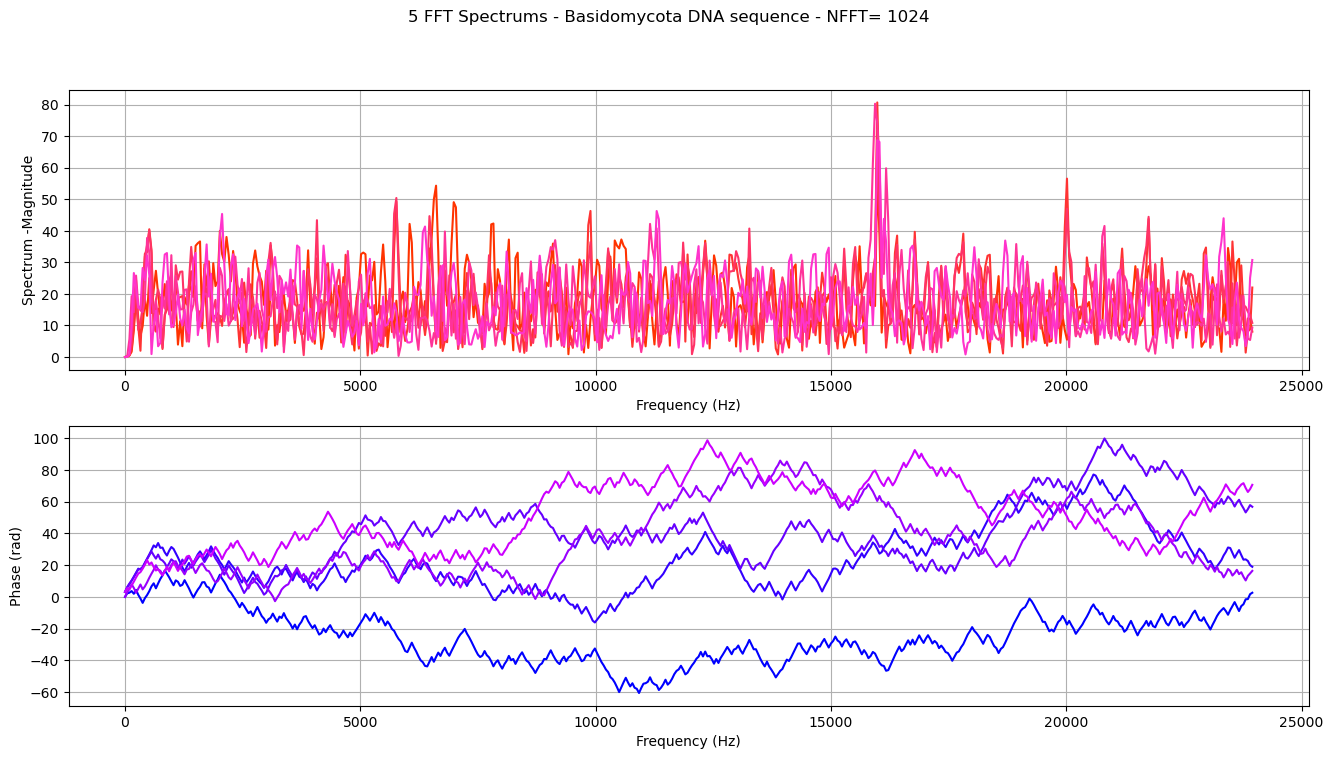

In [141]:
fig, axs = plt.subplots(2, figsize=(16,8))
fig.suptitle("5 FFT Spectrums - Basidomycota DNA sequence - NFFT= "+str(NFFT))
#  FFT Magnitude - HIGH-Pass 
for j in range(5) :
        #  FFT magnitude
        axs[0].plot(xx,np.abs(spectrum_FB[j]),color=(1, 0.2, j/5))
        #  FFT phase
        axs[1].plot(xx,np.unwrap(np.angle(spectrum_FB[j])),color=(j/5, 0, 1))
#--------------------------
axs[0].set_xlabel("Frequency (Hz)") 
axs[0].set_ylabel("Spectrum -Magnitude")
axs[0].grid()
#axs[0].grid(b=True, which='major', color='g', linestyle='-')
#axs[0].grid(b=True, which='minor', color='g', linestyle='--')
#-----------------------------------------------------------------
axs[1].set_xlabel("Frequency (Hz)") 
axs[1].set_ylabel("Phase (rad)")
axs[1].grid()
#axs[1].legend(['FFT', 'FFT w. window'])
#axs[1].grid(b=True, which='major', color='g', linestyle='-')
#axs[1].grid(b=True, which='minor', color='g', linestyle='--')
plt.show()

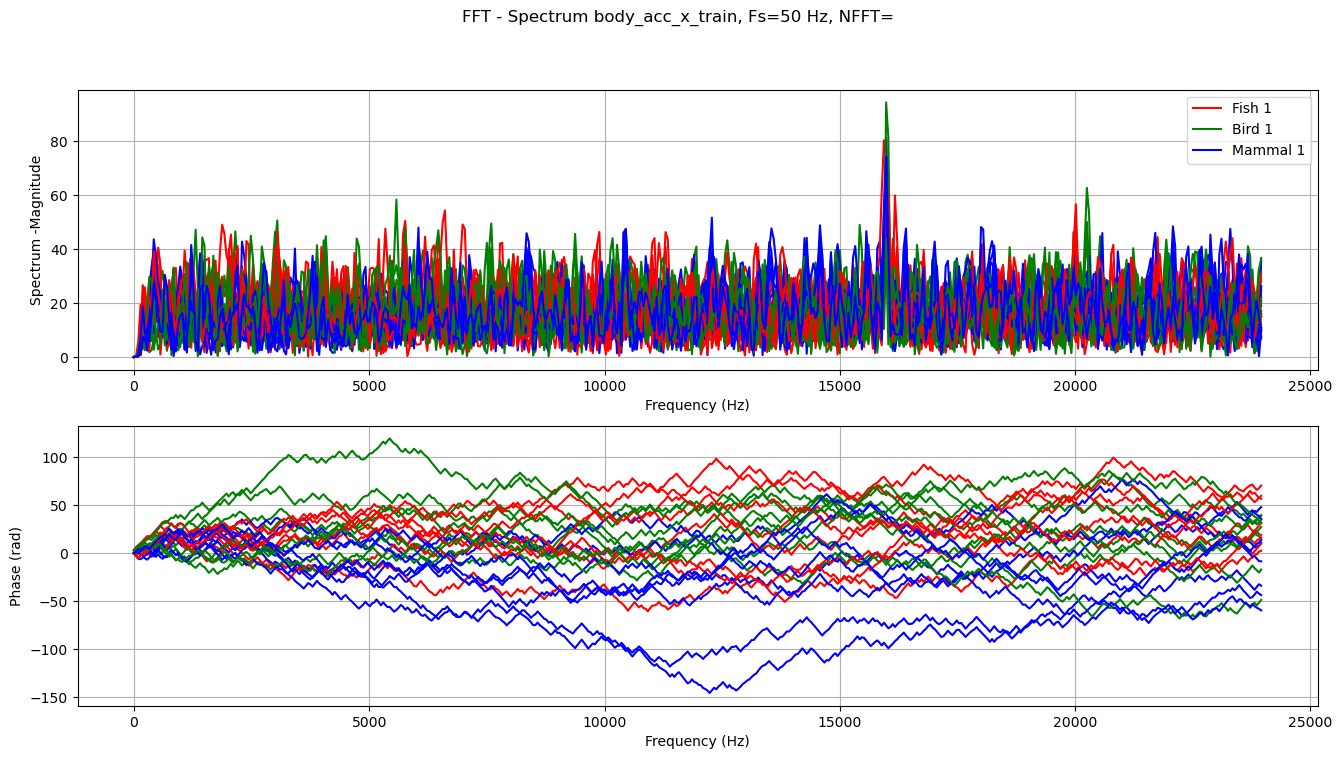

In [142]:
fig, axs = plt.subplots(2, figsize=(16,8))
fig.suptitle("FFT - Spectrum body_acc_x_train, Fs=50 Hz, NFFT=")
# FFT magnitude

for j in range(8) :
    
#  Spectrum magnitude
#--------------------------
    axs[0].plot(xx,np.abs(spectrum_FB[j]),color='r')
    axs[0].plot(xx,np.abs(spectrum_FP[j]),color='g')
    axs[0].plot(xx,np.abs(spectrum_FS[j]),color='b')

#  FFT Spectrum
#--------------------------
    axs[1].plot(xx,np.unwrap(np.angle(spectrum_FB[j])),color='r')
    axs[1].plot(xx,np.unwrap(np.angle(spectrum_FP[j])),color='g')
    axs[1].plot(xx,np.unwrap(np.angle(spectrum_FS[j])),color='b')

#--------------------------
axs[0].legend(['Fish 1', 'Bird 1', 'Mammal 1'])
axs[0].set_xlabel("Frequency (Hz)") 
axs[0].set_ylabel("Spectrum -Magnitude")
axs[0].grid()
#axs[0].grid(b=True, which='major', color='g', linestyle='-')
#axs[0].grid(b=True, which='minor', color='g', linestyle='--')

axs[1].set_xlabel("Frequency (Hz)") 
axs[1].set_ylabel("Phase (rad)")
#axs[1].legend(['FFT', 'FFT w. window'])
axs[1].grid()
#axs[1].grid(b=True, which='major', color='g', linestyle='-')
#axs[1].grid(b=True, which='minor', color='g', linestyle='--')
#plt.show()

#  CLASSIFICATION

##   Dataframe, Labels, Features. 

Convert Spectrum to pandas dataframe 

In [143]:
spectrum_FB_Mag=np.abs(spectrum_FB)
spectrum_FP_Mag=np.abs(spectrum_FP)
spectrum_FS_Mag=np.abs(spectrum_FS)

In [144]:
spectrum_FB_Phas=np.unwrap(np.angle(spectrum_FB))
spectrum_FS_Phas=np.unwrap(np.angle(spectrum_FS))
spectrum_FP_Phas=np.unwrap(np.angle(spectrum_FP))

We concatenate FFT spectrums magnitude and phase.  Number of features = NFFT

In [145]:
spec_FB=np.append(spectrum_FB_Mag, spectrum_FB_Phas, axis=1)
spec_FP=np.append(spectrum_FP_Mag, spectrum_FP_Phas, axis=1)
spec_FS=np.append(spectrum_FS_Mag, spectrum_FS_Phas, axis=1)

For testing FFT spectrum magnitude only !  Number of features = NFFT//2

#FFT spectrum magnitude only !  
spec_FB=spectrum_FB_Mag
spec_FP=spectrum_FP_Mag
spec_FS=spectrum_FS_Mag

In [209]:
df_FB = pd.DataFrame(spec_FB)
df_FP = pd.DataFrame(spec_FP)
df_FS = pd.DataFrame(spec_FS)

#### We create 3 classes, one for each fungi phylum or subphylum. 
For each dataframe we append a new column "class"  B=0  P=1  S=2 

In [210]:
listFB =  [0] * len(df_FB)
listFP =  [1] * len(df_FP)
listFS =  [2] * len(df_FS)
df_FB['Class'] = listFB
df_FP['Class'] = listFP
df_FS['Class'] = listFS

We create a large spectrum DATAFRAME     

In [211]:
df_FBFPFS= pd.concat([df_FB,  df_FP, df_FS],axis=0)
df_FBFPFS.shape   #, df_FBFPFSt.shape

(224, 1025)

In [212]:
df_FBFPFS.reset_index(inplace=True, drop=True) 

In [213]:
df_FBFPFS.head()

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,Class
0,2.119802e-08,0.134396,0.449732,1.664216,8.591256,21.216286,12.407815,6.677589,9.813164,18.394594,...,-3.267149,-6.069481,-8.887266,-5.785465,-4.600811,-1.482212,-1.355993,1.722942,2.638467,0
1,1.452130e-08,0.126457,0.580041,2.414698,9.934915,17.420065,9.721469,1.978967,20.068871,32.733228,...,24.654521,27.198300,29.462725,26.350238,23.442124,23.634299,22.614139,20.003144,18.940688,0
2,8.663548e-09,0.090848,0.637145,4.280907,17.141734,24.384495,8.605131,11.171615,15.263681,31.772166,...,56.871906,59.370849,61.125546,58.121571,55.773820,53.171548,55.225937,57.776303,56.715179,0
3,1.416916e-08,0.229875,5.703102,19.284451,14.198145,25.789328,16.464347,14.764466,14.222516,17.977220,...,14.963531,17.047835,14.332381,15.531434,12.683899,10.363727,13.273003,14.768803,16.383503,0
4,1.549411e-08,0.084656,0.788796,9.507785,26.601225,22.137872,15.598593,15.184979,28.220593,24.369494,...,64.282230,67.341970,69.003295,70.710925,71.564282,68.522810,66.026578,67.820613,70.516853,0


In [214]:
Y = df_FBFPFS['Class'].to_numpy()
Y[0:100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

In [215]:
df_FBFPFS.shape[1]

1025

In [216]:
#col_i= np.arange(0, NFFT, 1, dtype=int)
col_i= np.arange(0, df_FBFPFS.shape[1]-1, 1, dtype=int)
list_col_i= col_i.tolist()
df1 = df_FBFPFS[list_col_i]
X0=df1.to_numpy()

In [217]:
X0.shape

(224, 1024)

In [218]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X0)

In [219]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.25, random_state=11,  stratify= Y)

In [220]:
Y_train[0:20]
Y_test

array([1, 0, 1, 1, 0, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 0, 1, 2, 0, 2, 2,
       1, 0, 1, 1, 2, 1, 2, 2, 0, 1, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 2, 1,
       2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 0, 1], dtype=int64)

In [221]:
print( X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(168, 1024) (56, 1024) (168,) (56,)


##  <span style="color:#0094cf;"> Logistic Regression </span>

In [222]:
parameters ={"C":[0.001,0.005, 0.01, 0.05, 0.1, 1, 5],'penalty':['l2'], 'solver':('newton-cg', 'lbfgs', 'liblinear')}# l1 lasso l2 ridge

lr=LogisticRegression(max_iter=1500)
print(parameters)

{'C': [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5], 'penalty': ['l2'], 'solver': ('newton-cg', 'lbfgs', 'liblinear')}


In [223]:
logreg_cv=GridSearchCV(estimator=lr, param_grid=parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(max_iter=1500),
             param_grid={'C': [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5],
                         'penalty': ['l2'],
                         'solver': ('newton-cg', 'lbfgs', 'liblinear')})

In [224]:
print("Best parameter:",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

Best parameter: {'C': 0.05, 'penalty': 'l2', 'solver': 'newton-cg'}
accuracy : 0.8981617647058823


In [225]:
acc_LR=logreg_cv.score(X_test, Y_test);
print('Accuracy:', acc_LR)

Accuracy: 0.9821428571428571


In [226]:
yhat_LR= logreg_cv.predict(X_test)
print (classification_report(Y_test, yhat_LR, target_names=['Basidiomycota', 'Pezizomycotina','Saccharomycotina']))  

                  precision    recall  f1-score   support

   Basidiomycota       1.00      1.00      1.00         7
  Pezizomycotina       1.00      0.96      0.98        26
Saccharomycotina       0.96      1.00      0.98        23

        accuracy                           0.98        56
       macro avg       0.99      0.99      0.99        56
    weighted avg       0.98      0.98      0.98        56



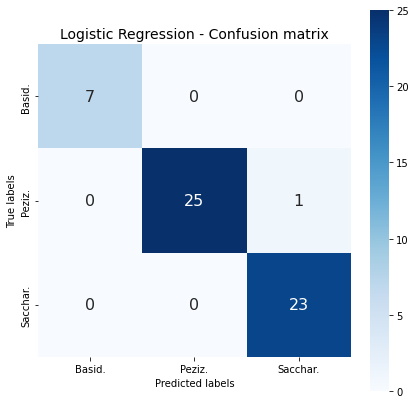

In [227]:
yhat_LR=logreg_cv.predict(X_test)
fig=plt.figure(figsize=(7,7))
plot_confusion_matrix(Y_test,yhat_LR)
plt.title("Logistic Regression - Confusion matrix", fontsize=14)
plt.savefig("LOG_REG_Fungi_figure1.png")

Comment HERE !  

## <span style="color:#0094cf;"> Support Vector Machine </span>

In [228]:
parameters = {'kernel':('linear','poly','rbf'),
              'C': np.logspace(-4, 2, 12),
              'gamma':np.logspace(-5, 2, 7)}
svm = SVC()

print(np.logspace(-3, 2, 18))

[1.00000000e-03 1.96841945e-03 3.87467512e-03 7.62698586e-03
 1.50131073e-02 2.95520924e-02 5.81709133e-02 1.14504757e-01
 2.25393390e-01 4.43668733e-01 8.73326162e-01 1.71907220e+00
 3.38385515e+00 6.66084629e+00 1.31113394e+01 2.58086154e+01
 5.08021805e+01 1.00000000e+02]


In [229]:
svm_cv = GridSearchCV(svm,parameters,cv=10)
svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': array([1.00000000e-04, 3.51119173e-04, 1.23284674e-03, 4.32876128e-03,
       1.51991108e-02, 5.33669923e-02, 1.87381742e-01, 6.57933225e-01,
       2.31012970e+00, 8.11130831e+00, 2.84803587e+01, 1.00000000e+02]),
                         'gamma': array([1.00000000e-05, 1.46779927e-04, 2.15443469e-03, 3.16227766e-02,
       4.64158883e-01, 6.81292069e+00, 1.00000000e+02]),
                         'kernel': ('linear', 'poly', 'rbf')})

In [230]:
print("tuned hyperparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': 8.111308307896856, 'gamma': 0.00014677992676220705, 'kernel': 'rbf'}
accuracy : 0.9099264705882353


In [231]:
acc_svm=svm_cv.score(X_test, Y_test);
print('Accuracy:', acc_svm)

Accuracy: 0.9642857142857143


In [232]:
yhat_svm= svm_cv.predict(X_test)
print (classification_report(Y_test, yhat_svm, target_names=['Basidiomycota', 'Pezizomycotina','Saccharomycotina'])) 

                  precision    recall  f1-score   support

   Basidiomycota       1.00      1.00      1.00         7
  Pezizomycotina       1.00      0.92      0.96        26
Saccharomycotina       0.92      1.00      0.96        23

        accuracy                           0.96        56
       macro avg       0.97      0.97      0.97        56
    weighted avg       0.97      0.96      0.96        56



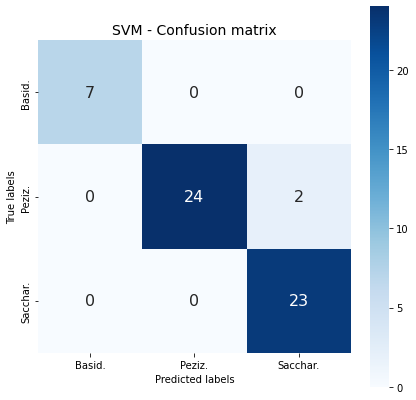

In [233]:
fig=plt.figure(figsize=(7,7))
plot_confusion_matrix(Y_test,yhat_svm)
plt.title("SVM - Confusion matrix", fontsize=14)
plt.savefig("SVM_REG_Fungi_figure2.png")